# 01 - Análisis Descriptivo Exploratorio (ADE)

## Proyecto: "¿Regular o no regular? Impacto de la regulación de IA en los ecosistemas nacionales"

**Contexto:** Chile - Boletín 16821-19 (Ley Marco de IA)

---

## Objetivos del ADE

1. Comprender la estructura del dataset final
2. Identificar patrones en regulación IA (X1) y resultados del ecosistema (Y)
3. Detectar relaciones preliminares entre regulación y desarrollo del ecosistema IA
4. Preparar el terreno para el modelamiento estadístico
5. Generar visualizaciones que informen la interpretación de resultados

## 1. Setup y Carga de Datos

In [1]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import f_oneway, kruskal
import warnings
warnings.filterwarnings('ignore')

# Configuración de visualizaciones
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('viridis')

# Rutas
DATA_PATH = '../data/interim/'
OUTPUTS_PATH = './outputs/'

# Crear directorio de outputs si no existe
import os
os.makedirs(OUTPUTS_PATH, exist_ok=True)

print("✓ Setup completado")

✓ Setup completado


In [2]:
%pip install --quiet --upgrade pandas matplotlib seaborn scipy

Note: you may need to restart the kernel to use updated packages.


In [3]:
# Cargar dataset definitivo
df = pd.read_csv(f'{DATA_PATH}sample_ready_cross_section.csv')

print(f"Dataset cargado: {df.shape[0]} países × {df.shape[1]} variables")
print(f"\nColumnas disponibles: {list(df.columns)[:20]}...")

Dataset cargado: 86 países × 105 variables

Columnas disponibles: ['iso3', 'has_ai_law', 'regulatory_approach', 'regulatory_intensity', 'year_enacted', 'enforcement_level', 'thematic_coverage', 'regulatory_status_group', 'x1_source', 'ai_patents_per100k', 'ai_investment_usd_bn_cumulative', 'ai_investment_usd_bn_2024', 'ai_startups_cumulative', 'ai_startups_2024', 'patents_year', 'investment_year', 'startups_year', 'ai_adoption_rate', 'adoption_period', 'ai_readiness_score']...


## 2. Filtrar a Muestra Principal

In [4]:
# Ver flags de completitud
print("=== Flags de completitud ===")
print(f"complete_principal: {df['complete_principal'].sum()} países")
print(f"complete_confounded: {df['complete_confounded'].sum()} países")
print(f"complete_extended: {df['complete_extended'].sum()} países")
print(f"complete_digital: {df['complete_digital'].sum()} países")
print(f"complete_regime: {df['complete_regime'].sum()} países")
print(f"complete_legal_tradition: {df['complete_legal_tradition'].sum()} países")

=== Flags de completitud ===
complete_principal: 72 países
complete_confounded: 72 países
complete_extended: 62 países
complete_digital: 69 países
complete_regime: 72 países
complete_legal_tradition: 72 países


In [5]:
# Filtrar a muestra principal para análisis
df_ade = df[df['complete_principal'] == 1].copy()
print(f"\n✓ Análisis con {len(df_ade)} países (muestra PRINCIPAL)")

# También preparar muestra confounded para análisis robusto
df_confounded = df[df['complete_confounded'] == 1].copy()
print(f"✓ Análisis robusto con {len(df_confounded)} países (muestra CONFOUNDED)")


✓ Análisis con 72 países (muestra PRINCIPAL)
✓ Análisis robusto con 72 países (muestra CONFOUNDED)


## 3. Definir Variables Clave

In [6]:
# Variables Y (Resultado - Ecosistema IA)
y_vars = [
    'ai_readiness_score',
    'ai_adoption_rate',
    'ai_investment_usd_bn_cumulative',
    'ai_startups_cumulative',
    'ai_patents_per100k'
]

# Variables X1 (Tratamiento - Regulación IA)
x1_vars = [
    'has_ai_law',
    'regulatory_approach',
    'regulatory_intensity',
    'enforcement_level',
    'thematic_coverage',
    'regulatory_status_group'
]

# Variables X2 (Controles)
x2_core_vars = [
    'gdp_per_capita_ppp',
    'internet_penetration',
    'gii_score',
    'rd_expenditure',
    'tertiary_education'
]

# Variables X2 Confounders (post-auditoría)
x2_confounders = [
    'regulatory_quality',
    'rule_of_law',
    'has_gdpr_like_law',
    'gdpr_similarity_level',
    'fh_total_score',
    'legal_origin',
    'is_common_law'
]

print("Variables definidas:")
print(f"  - Y (Resultado): {len(y_vars)} variables")
print(f"  - X1 (Regulación): {len(x1_vars)} variables")
print(f"  - X2 Core (Controles): {len(x2_core_vars)} variables")
print(f"  - X2 Confounders: {len(x2_confounders)} variables")

Variables definidas:
  - Y (Resultado): 5 variables
  - X1 (Regulación): 6 variables
  - X2 Core (Controles): 5 variables
  - X2 Confounders: 7 variables


## 4. Estadísticas Descriptivas Generales

In [7]:
# 4.1 Resumen de variables Y
print("=== Variables Y (Ecosistema IA) ===")
desc_y = df_ade[y_vars].describe()
print(desc_y.round(2))

=== Variables Y (Ecosistema IA) ===
       ai_readiness_score  ai_adoption_rate  ai_investment_usd_bn_cumulative  \
count               72.00             72.00                            72.00   
mean                60.89             23.86                            10.45   
std                 12.43             12.25                            56.93   
min                 32.47              6.60                             0.00   
25%                 53.72             14.68                             0.02   
50%                 60.90             22.45                             0.33   
75%                 69.97             28.98                             2.19   
max                 88.36             64.00                           470.92   

       ai_startups_cumulative  ai_patents_per100k  
count                   72.00               49.00  
mean                   198.75                0.85  
std                    842.19                2.71  
min                      1.00      

In [8]:
# 4.2 Resumen de variables X1
print("\n=== Variables X1 (Regulación IA) ===")

# Distribución de has_ai_law
print("\nhas_ai_law:")
print(df_ade['has_ai_law'].value_counts())

# Distribución de regulatory_approach
print("\nregulatory_approach:")
print(df_ade['regulatory_approach'].value_counts())

# Distribución de regulatory_status_group
print("\nregulatory_status_group:")
print(df_ade['regulatory_status_group'].value_counts())

# Distribución de enforcement_level
print("\nenforcement_level:")
print(df_ade['enforcement_level'].value_counts())


=== Variables X1 (Regulación IA) ===

has_ai_law:
has_ai_law
0    45
1    27
Name: count, dtype: int64

regulatory_approach:
regulatory_approach
strategy_led     34
comprehensive    27
light_touch       9
none              2
Name: count, dtype: int64

regulatory_status_group:
regulatory_status_group
strategy_only         34
binding_regulation    27
soft_framework         9
no_framework           2
Name: count, dtype: int64

enforcement_level:
enforcement_level
high      26
low       25
medium    13
none       8
Name: count, dtype: int64


In [9]:
# 4.3 Resumen de regulatory_intensity y thematic_coverage
print("\n=== Variables X1 Numéricas ===")

print("\nregulatory_intensity (0-10):")
print(df_ade['regulatory_intensity'].describe())

print("\nthematic_coverage (0-15):")
print(df_ade['thematic_coverage'].describe())


=== Variables X1 Numéricas ===

regulatory_intensity (0-10):
count    72.000000
mean      5.402778
std       3.495106
min       0.000000
25%       2.750000
50%       4.000000
75%      10.000000
max      10.000000
Name: regulatory_intensity, dtype: float64

thematic_coverage (0-15):
count    72.000000
mean      8.597222
std       4.719333
min       0.000000
25%       4.750000
50%       8.000000
75%      14.000000
max      14.000000
Name: thematic_coverage, dtype: float64


In [10]:
# 4.4 Resumen de variables X2 Core
print("\n=== Variables X2 Core (Controles) ===")
desc_x2 = df_ade[x2_core_vars].describe()
print(desc_x2.round(2))


=== Variables X2 Core (Controles) ===
       gdp_per_capita_ppp  internet_penetration  gii_score  rd_expenditure  \
count               72.00                 72.00      72.00           65.00   
mean             44775.63                 84.32      38.43            1.48   
std              29782.71                 16.66      12.74            1.25   
min               3273.27                  8.95      17.07            0.08   
25%              18958.22                 81.80      28.45            0.55   
50%              43148.33                 88.62      37.14            1.15   
75%              62010.68                 94.37      48.66            2.10   
max             150689.30                100.00      65.96            6.02   

       tertiary_education  
count               69.00  
mean                67.98  
std                 27.17  
min                 10.42  
25%                 53.46  
50%                 70.45  
75%                 81.18  
max                165.11  


## 5. Análisis por Grupo Regulatorio

In [11]:
# 5.1 Distribución de grupos regulatorios
print("=== Distribución de Grupos Regulatorios (N=72) ===")
group_dist = df_ade['regulatory_status_group'].value_counts()
print(group_dist)

# Porcentajes
group_pct = (group_dist / len(df_ade) * 100).round(1)
print("\nPorcentajes:")
for group, pct in group_pct.items():
    print(f"  {group}: {pct}%")

=== Distribución de Grupos Regulatorios (N=72) ===
regulatory_status_group
strategy_only         34
binding_regulation    27
soft_framework         9
no_framework           2
Name: count, dtype: int64

Porcentajes:
  strategy_only: 47.2%
  binding_regulation: 37.5%
  soft_framework: 12.5%
  no_framework: 2.8%


In [12]:
# 5.2 Tabla resumen: media de Y por grupo regulatorio
print("\n=== Media de Variables Y por Grupo Regulatorio ===")
y_by_group = df_ade.groupby('regulatory_status_group')[y_vars].agg(['mean', 'std', 'count'])
print(y_by_group.round(2))


=== Media de Variables Y por Grupo Regulatorio ===
                        ai_readiness_score              ai_adoption_rate  \
                                      mean    std count             mean   
regulatory_status_group                                                    
binding_regulation                   66.76   8.46    27            27.43   
no_framework                         34.58   0.46     2            16.75   
soft_framework                       50.17  14.83     9            16.33   
strategy_only                        60.61  11.02    34            23.43   

                                     ai_investment_usd_bn_cumulative         \
                           std count                            mean    std   
regulatory_status_group                                                       
binding_regulation        8.87    27                            6.80  22.78   
no_framework             12.66     2                            0.01   0.01   
soft_framework      

In [13]:
# 5.3 Tabla resumen: media de X2 por grupo regulatorio
print("\n=== Media de Variables X2 por Grupo Regulatorio ===")
x2_by_group = df_ade.groupby('regulatory_status_group')[x2_core_vars].agg(['mean', 'std'])
print(x2_by_group.round(2))


=== Media de Variables X2 por Grupo Regulatorio ===
                        gdp_per_capita_ppp           internet_penetration  \
                                      mean       std                 mean   
regulatory_status_group                                                     
binding_regulation                59331.06  21148.32                91.28   
no_framework                       9081.91   4939.74                61.27   
soft_framework                    30513.09  29188.94                71.43   
strategy_only                     39091.92  31771.61                83.55   

                               gii_score        rd_expenditure        \
                           std      mean    std           mean   std   
regulatory_status_group                                                
binding_regulation        4.76     45.81   9.73           2.01  1.15   
no_framework             27.38     20.90   3.84            NaN   NaN   
soft_framework           27.89     33.13  16.32

## 6. Visualizaciones

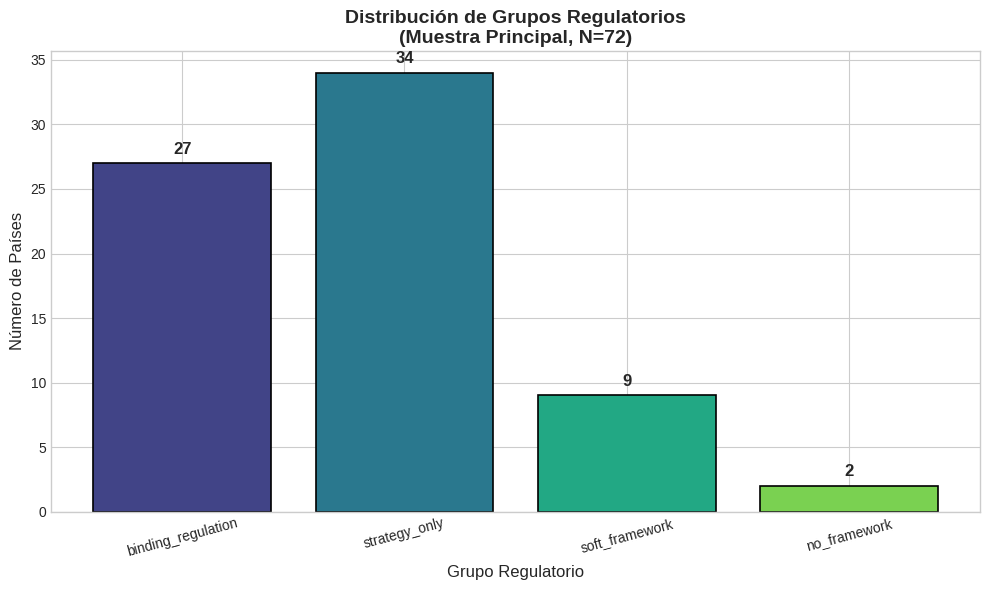

✓ Guardado: ./outputs/ade_01_group_distribution.png


In [14]:
# 6.1 Distribución de grupos regulatorios (barras)
fig, ax = plt.subplots(figsize=(10, 6))

group_order = ['binding_regulation', 'strategy_only', 'soft_framework', 'no_framework']
colors = sns.color_palette('viridis', n_colors=4)

group_counts = df_ade['regulatory_status_group'].value_counts().reindex(group_order)
bars = ax.bar(group_order, group_counts.values, color=colors, edgecolor='black', linewidth=1.2)

ax.set_xlabel('Grupo Regulatorio', fontsize=12)
ax.set_ylabel('Número de Países', fontsize=12)
ax.set_title('Distribución de Grupos Regulatorios\n(Muestra Principal, N=72)', fontsize=14, fontweight='bold')

# Añadir etiquetas
for bar, count in zip(bars, group_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, 
            str(count), ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig(f'{OUTPUTS_PATH}ade_01_group_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"✓ Guardado: {OUTPUTS_PATH}ade_01_group_distribution.png")

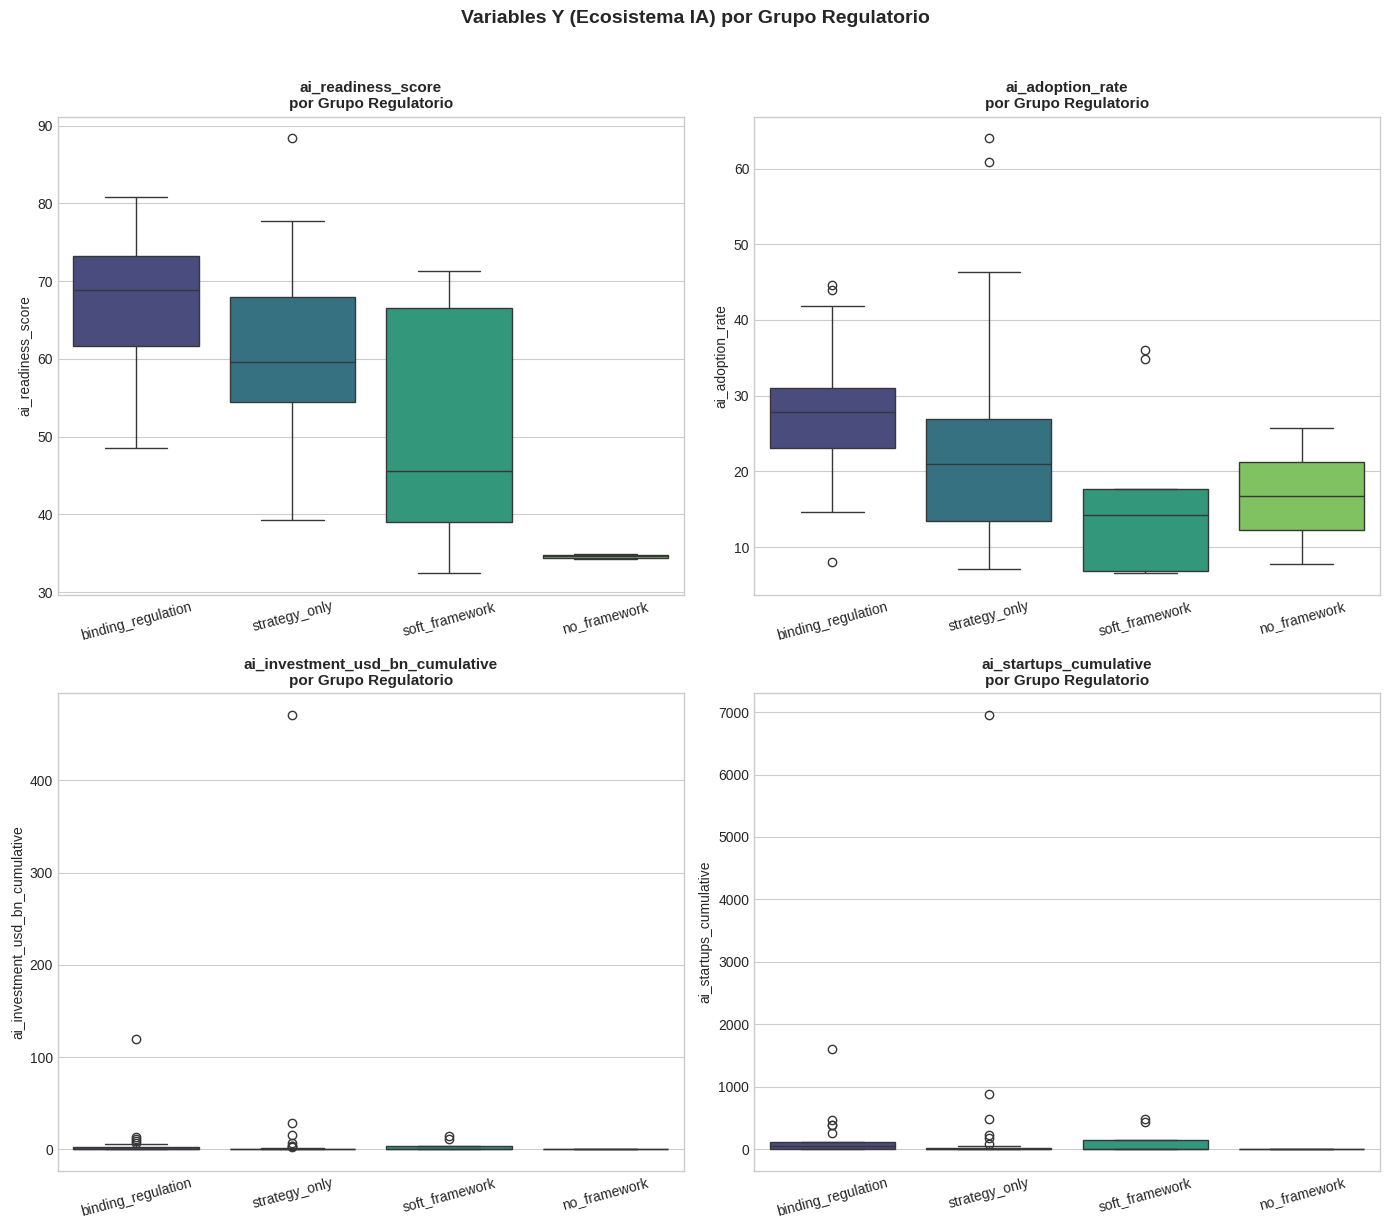

✓ Guardado: ./outputs/ade_02_y_by_regulatory_group.png


In [15]:
# 6.2 Boxplots de variables Y por grupo regulatorio
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

y_plot_vars = ['ai_readiness_score', 'ai_adoption_rate', 
               'ai_investment_usd_bn_cumulative', 'ai_startups_cumulative']

for i, var in enumerate(y_plot_vars):
    sns.boxplot(data=df_ade, x='regulatory_status_group', y=var, 
                order=group_order, palette='viridis', ax=axes[i])
    axes[i].set_title(f'{var}\npor Grupo Regulatorio', fontsize=11, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=15)

plt.suptitle('Variables Y (Ecosistema IA) por Grupo Regulatorio', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{OUTPUTS_PATH}ade_02_y_by_regulatory_group.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"✓ Guardado: {OUTPUTS_PATH}ade_02_y_by_regulatory_group.png")

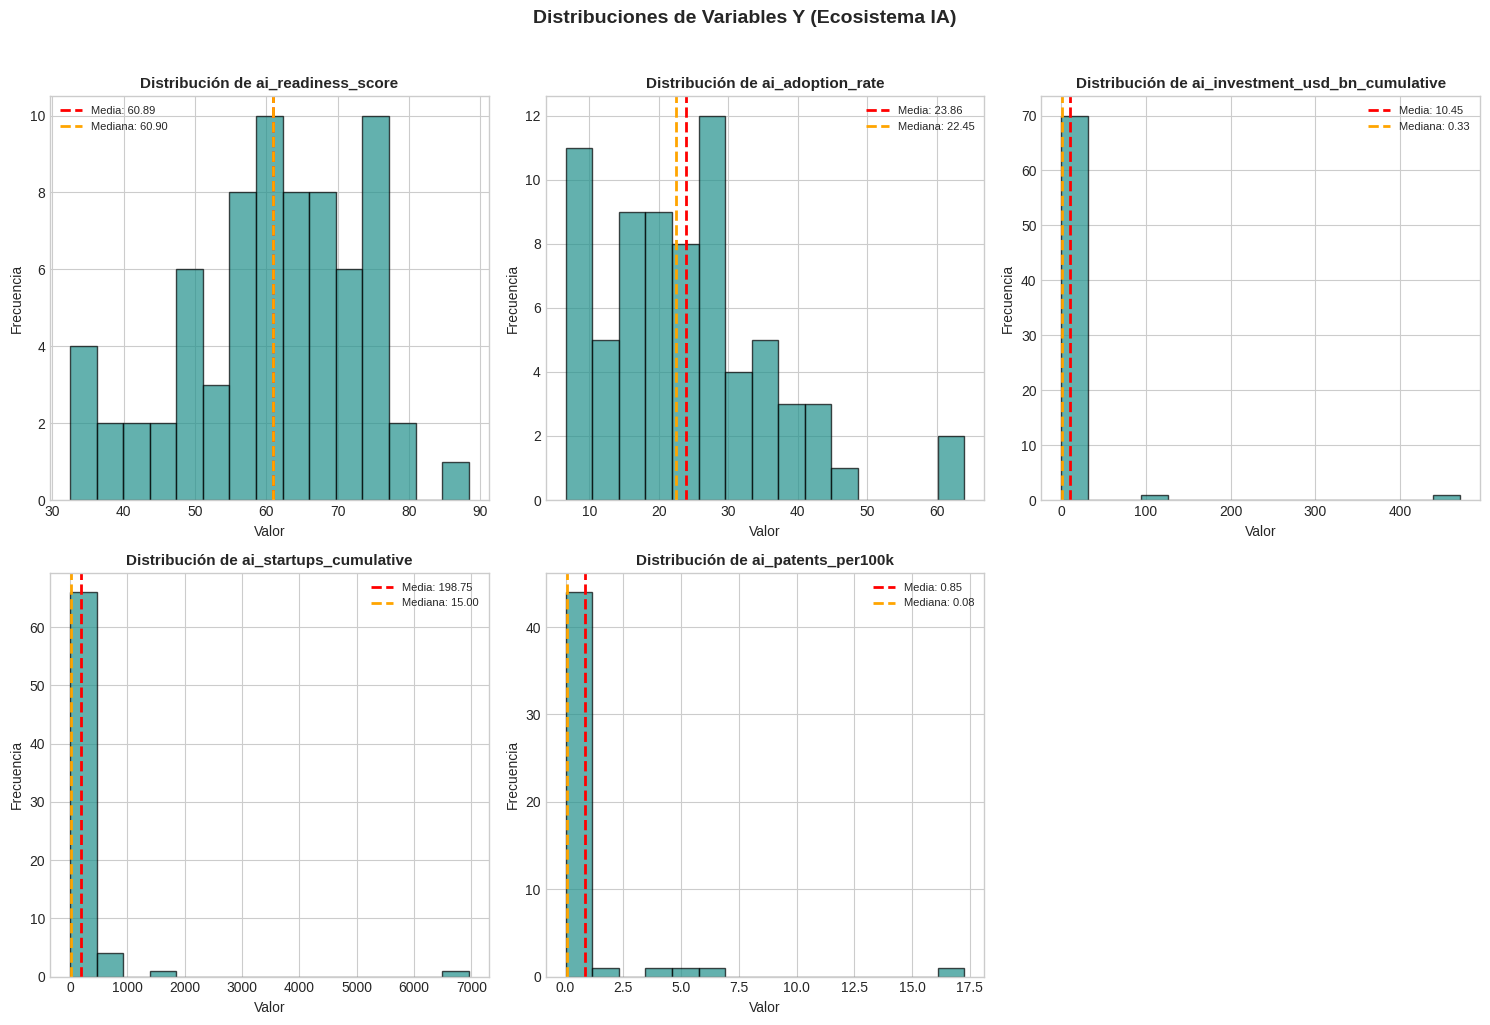

✓ Guardado: ./outputs/ade_03_y_distributions.png


In [16]:
# 6.3 Histogramas de variables Y
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, var in enumerate(y_vars):
    data = df_ade[var].dropna()
    axes[i].hist(data, bins=15, color=sns.color_palette('viridis', 1)[0], 
                 edgecolor='black', alpha=0.7)
    axes[i].axvline(data.mean(), color='red', linestyle='--', linewidth=2, label=f'Media: {data.mean():.2f}')
    axes[i].axvline(data.median(), color='orange', linestyle='--', linewidth=2, label=f'Mediana: {data.median():.2f}')
    axes[i].set_title(f'Distribución de {var}', fontsize=11, fontweight='bold')
    axes[i].set_xlabel('Valor')
    axes[i].set_ylabel('Frecuencia')
    axes[i].legend(fontsize=8)

# Ocultar el último subplot vacío
axes[-1].axis('off')

plt.suptitle('Distribuciones de Variables Y (Ecosistema IA)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{OUTPUTS_PATH}ade_03_y_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"✓ Guardado: {OUTPUTS_PATH}ade_03_y_distributions.png")

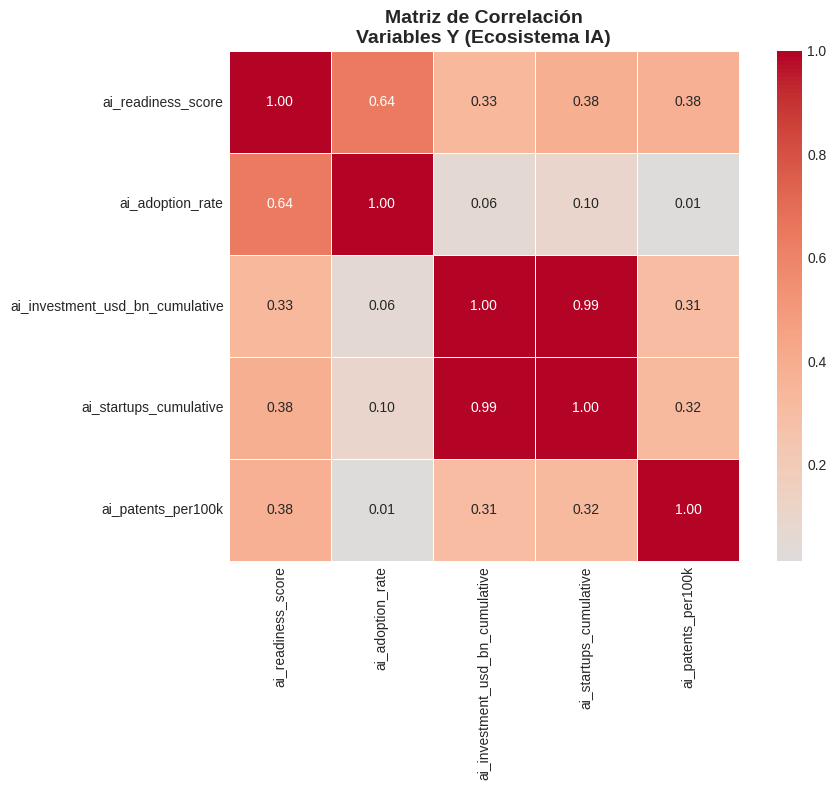

✓ Guardado: ./outputs/ade_04_y_correlation_matrix.png


In [17]:
# 6.4 Matriz de correlación de variables Y
fig, ax = plt.subplots(figsize=(10, 8))

corr_matrix = df_ade[y_vars].corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5, ax=ax,
            annot_kws={'size': 10})

ax.set_title('Matriz de Correlación\nVariables Y (Ecosistema IA)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig(f'{OUTPUTS_PATH}ade_04_y_correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"✓ Guardado: {OUTPUTS_PATH}ade_04_y_correlation_matrix.png")

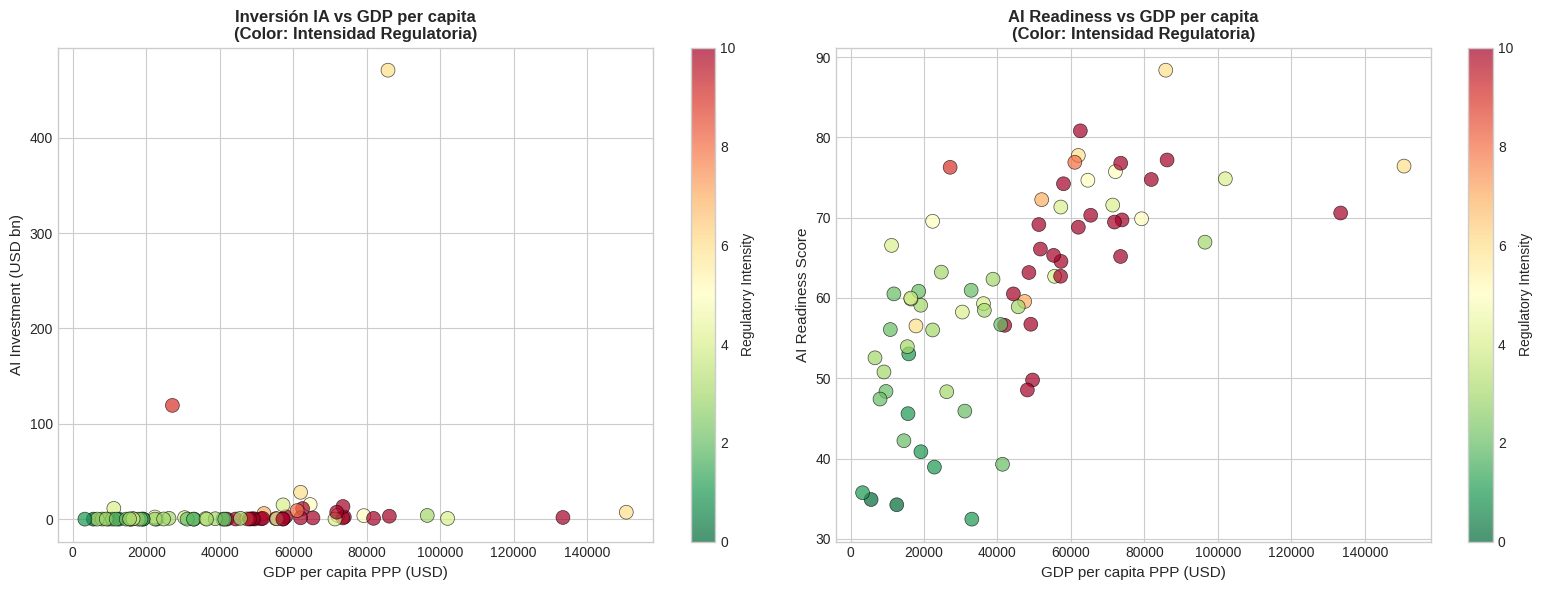

✓ Guardado: ./outputs/ade_05_scatter_gdp_outcomes.png


In [18]:
# 6.5 Scatterplot: GDP vs AI Investment con color por intensidad regulatoria
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Scatter 1: GDP vs Investment
scatter1 = axes[0].scatter(df_ade['gdp_per_capita_ppp'], 
                           df_ade['ai_investment_usd_bn_cumulative'],
                           c=df_ade['regulatory_intensity'], 
                           cmap='RdYlGn_r', alpha=0.7, s=100, edgecolor='black', linewidth=0.5)
axes[0].set_xlabel('GDP per capita PPP (USD)', fontsize=11)
axes[0].set_ylabel('AI Investment (USD bn)', fontsize=11)
axes[0].set_title('Inversión IA vs GDP per capita\n(Color: Intensidad Regulatoria)', fontsize=12, fontweight='bold')
plt.colorbar(scatter1, ax=axes[0], label='Regulatory Intensity')

# Scatter 2: GDP vs Readiness
scatter2 = axes[1].scatter(df_ade['gdp_per_capita_ppp'], 
                           df_ade['ai_readiness_score'],
                           c=df_ade['regulatory_intensity'], 
                           cmap='RdYlGn_r', alpha=0.7, s=100, edgecolor='black', linewidth=0.5)
axes[1].set_xlabel('GDP per capita PPP (USD)', fontsize=11)
axes[1].set_ylabel('AI Readiness Score', fontsize=11)
axes[1].set_title('AI Readiness vs GDP per capita\n(Color: Intensidad Regulatoria)', fontsize=12, fontweight='bold')
plt.colorbar(scatter2, ax=axes[1], label='Regulatory Intensity')

plt.tight_layout()
plt.savefig(f'{OUTPUTS_PATH}ade_05_scatter_gdp_outcomes.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"✓ Guardado: {OUTPUTS_PATH}ade_05_scatter_gdp_outcomes.png")

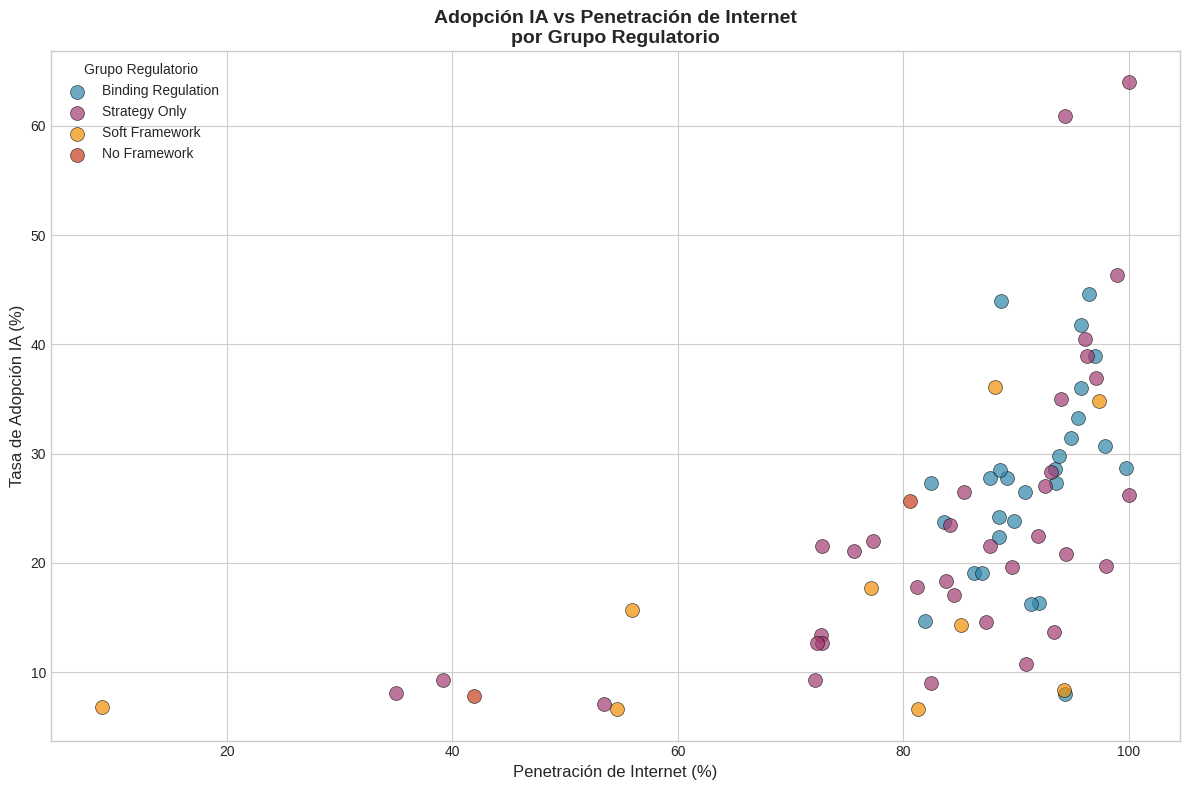

✓ Guardado: ./outputs/ade_06_adoption_vs_internet.png


In [19]:
# 6.6 Scatterplot: Internet vs Adoption con color por grupo
fig, ax = plt.subplots(figsize=(12, 8))

colors_map = {'binding_regulation': '#2E86AB', 'strategy_only': '#A23B72', 
               'soft_framework': '#F18F01', 'no_framework': '#C73E1D'}

for group in group_order:
    subset = df_ade[df_ade['regulatory_status_group'] == group]
    ax.scatter(subset['internet_penetration'], 
               subset['ai_adoption_rate'],
               c=colors_map[group], 
               label=group.replace('_', ' ').title(),
               alpha=0.7, s=100, edgecolor='black', linewidth=0.5)

ax.set_xlabel('Penetración de Internet (%)', fontsize=12)
ax.set_ylabel('Tasa de Adopción IA (%)', fontsize=12)
ax.set_title('Adopción IA vs Penetración de Internet\npor Grupo Regulatorio', fontsize=14, fontweight='bold')
ax.legend(title='Grupo Regulatorio', fontsize=10)

plt.tight_layout()
plt.savefig(f'{OUTPUTS_PATH}ade_06_adoption_vs_internet.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"✓ Guardado: {OUTPUTS_PATH}ade_06_adoption_vs_internet.png")

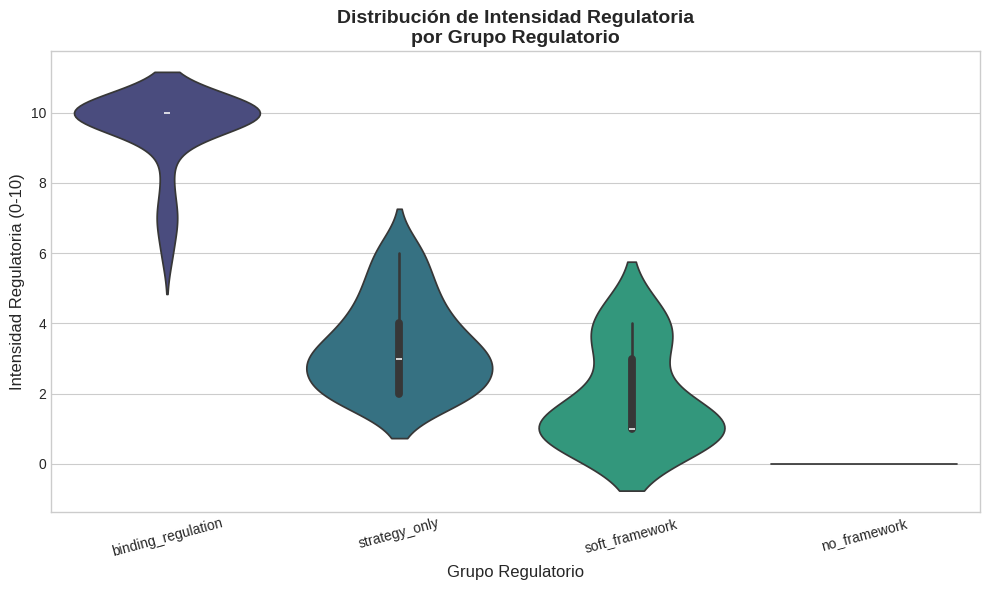

✓ Guardado: ./outputs/ade_07_regulatory_intensity.png


In [20]:
# 6.7 Regulatory Intensity por grupo
fig, ax = plt.subplots(figsize=(10, 6))

sns.violinplot(data=df_ade, x='regulatory_status_group', y='regulatory_intensity',
               order=group_order, palette='viridis', ax=ax)

ax.set_xlabel('Grupo Regulatorio', fontsize=12)
ax.set_ylabel('Intensidad Regulatoria (0-10)', fontsize=12)
ax.set_title('Distribución de Intensidad Regulatoria\npor Grupo Regulatorio', fontsize=14, fontweight='bold')
ax.tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig(f'{OUTPUTS_PATH}ade_07_regulatory_intensity.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"✓ Guardado: {OUTPUTS_PATH}ade_07_regulatory_intensity.png")

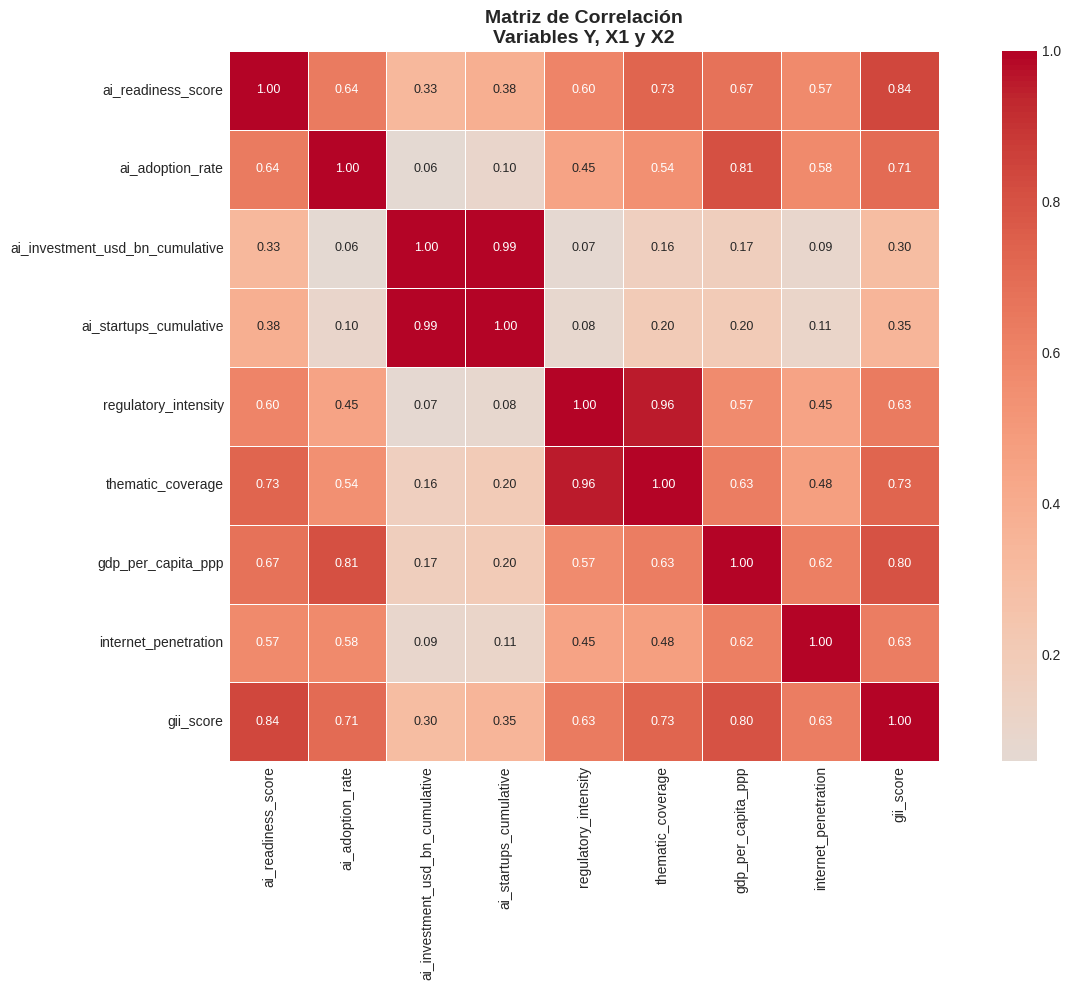

✓ Guardado: ./outputs/ade_08_full_correlation_matrix.png


In [21]:
# 6.8 Heatmap de correlaciones: Y vs X1 y X2
fig, ax = plt.subplots(figsize=(14, 10))

# Seleccionar variables numéricas relevantes
analysis_vars = ['ai_readiness_score', 'ai_adoption_rate', 
                 'ai_investment_usd_bn_cumulative', 'ai_startups_cumulative',
                 'regulatory_intensity', 'thematic_coverage',
                 'gdp_per_capita_ppp', 'internet_penetration', 'gii_score']

corr_full = df_ade[analysis_vars].corr()

sns.heatmap(corr_full, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5, ax=ax, annot_kws={'size': 9})

ax.set_title('Matriz de Correlación\nVariables Y, X1 y X2', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig(f'{OUTPUTS_PATH}ade_08_full_correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"✓ Guardado: {OUTPUTS_PATH}ade_08_full_correlation_matrix.png")

## 7. Tests Preliminares

In [22]:
# 7.1 Test ANOVA: Y por grupo regulatorio
print("=== Tests ANOVA por Grupo Regulatorio ===\n")

for var in y_vars:
    groups = [group[var].dropna() for name, group in df_ade.groupby('regulatory_status_group')]
    
    # Filtrar grupos vacíos
    groups = [g for g in groups if len(g) > 0]
    
    if len(groups) >= 2:
        f_stat, p_value = f_oneway(*groups)
        significance = "***" if p_value < 0.01 else "**" if p_value < 0.05 else "*" if p_value < 0.1 else ""
        print(f"{var}:")
        print(f"  F = {f_stat:.3f}, p = {p_value:.4f} {significance}")
        print()

=== Tests ANOVA por Grupo Regulatorio ===

ai_readiness_score:
  F = 9.959, p = 0.0000 ***

ai_adoption_rate:
  F = 2.248, p = 0.0906 *

ai_investment_usd_bn_cumulative:
  F = 0.201, p = 0.8955 

ai_startups_cumulative:
  F = 0.167, p = 0.9184 

ai_patents_per100k:
  F = 0.865, p = 0.4277 



In [23]:
# 7.2 Test Kruskal-Wallis (no paramétrico)
print("=== Tests Kruskal-Wallis (no paramétrico) ===\n")

for var in y_vars:
    groups = [group[var].dropna() for name, group in df_ade.groupby('regulatory_status_group')]
    groups = [g for g in groups if len(g) > 0]
    
    if len(groups) >= 2:
        h_stat, p_value = kruskal(*groups)
        significance = "***" if p_value < 0.01 else "**" if p_value < 0.05 else "*" if p_value < 0.1 else ""
        print(f"{var}:")
        print(f"  H = {h_stat:.3f}, p = {p_value:.4f} {significance}")
        print()

=== Tests Kruskal-Wallis (no paramétrico) ===

ai_readiness_score:
  H = 16.388, p = 0.0009 ***

ai_adoption_rate:
  H = 10.885, p = 0.0124 **

ai_investment_usd_bn_cumulative:
  H = 9.491, p = 0.0234 **

ai_startups_cumulative:
  H = 11.042, p = 0.0115 **

ai_patents_per100k:
  H = 10.450, p = 0.0054 ***



In [24]:
# 7.3 Correlaciones de Spearman entre X1 y Y
print("=== Correlaciones de Spearman: X1 vs Y ===\n")

x1_numeric = ['regulatory_intensity', 'thematic_coverage']

for x1 in x1_numeric:
    print(f"{x1}:")
    for y in y_vars:
        # Remover NaN
        data = df_ade[[x1, y]].dropna()
        if len(data) > 5:
            corr, p_value = stats.spearmanr(data[x1], data[y])
            significance = "***" if p_value < 0.01 else "**" if p_value < 0.05 else "*" if p_value < 0.1 else ""
            print(f"  vs {y}: ρ = {corr:.3f}, p = {p_value:.4f} {significance}")
    print()

=== Correlaciones de Spearman: X1 vs Y ===

regulatory_intensity:
  vs ai_readiness_score: ρ = 0.657, p = 0.0000 ***
  vs ai_adoption_rate: ρ = 0.603, p = 0.0000 ***
  vs ai_investment_usd_bn_cumulative: ρ = 0.616, p = 0.0000 ***
  vs ai_startups_cumulative: ρ = 0.614, p = 0.0000 ***
  vs ai_patents_per100k: ρ = 0.532, p = 0.0001 ***

thematic_coverage:
  vs ai_readiness_score: ρ = 0.675, p = 0.0000 ***
  vs ai_adoption_rate: ρ = 0.627, p = 0.0000 ***
  vs ai_investment_usd_bn_cumulative: ρ = 0.644, p = 0.0000 ***
  vs ai_startups_cumulative: ρ = 0.640, p = 0.0000 ***
  vs ai_patents_per100k: ρ = 0.563, p = 0.0000 ***



## 8. Análisis Especial: Chile

In [25]:
# 8.1 Chile en el dataset
chile = df_ade[df_ade['iso3'] == 'CHL']

if len(chile) > 0:
    print("=== CHILE en el Dataset ===\n")
    
    # Variables principales
    chile_vars = ['iso3', 'country_name_std', 'regulatory_approach', 'regulatory_intensity',
                  'has_ai_law', 'enforcement_level', 'thematic_coverage', 'regulatory_status_group']
    
    print("--- Regulación IA ---")
    for var in chile_vars:
        if var in chile.columns:
            print(f"{var}: {chile[var].values[0]}")
    
    print("\n--- Ecosistema IA (Y) ---")
    for var in y_vars:
        if var in chile.columns:
            val = chile[var].values[0]
            if pd.notna(val):
                print(f"{var}: {val:.2f}")
            else:
                print(f"{var}: N/A")
    
    print("\n--- Controles (X2) ---")
    for var in x2_core_vars:
        if var in chile.columns:
            val = chile[var].values[0]
            if pd.notna(val):
                print(f"{var}: {val:.2f}")
            else:
                print(f"{var}: N/A")
    
    print("--- Confounders ---")
    for var in ['legal_origin', 'gdpr_similarity_level', 'fh_total_score']:
        if var in chile.columns:
            print(f"{var}: {chile[var].values[0]}")

=== CHILE en el Dataset ===

--- Regulación IA ---
iso3: CHL
regulatory_approach: strategy_led
regulatory_intensity: 4
has_ai_law: 0
enforcement_level: low
thematic_coverage: 8
regulatory_status_group: strategy_only

--- Ecosistema IA (Y) ---
ai_readiness_score: 59.30
ai_adoption_rate: 20.80
ai_investment_usd_bn_cumulative: 0.68
ai_startups_cumulative: 17.00
ai_patents_per100k: 0.01

--- Controles (X2) ---
gdp_per_capita_ppp: 36181.16
internet_penetration: 94.46
gii_score: 33.07
rd_expenditure: 0.36
tertiary_education: 104.73
--- Confounders ---
legal_origin: French
gdpr_similarity_level: 2
fh_total_score: 94


In [26]:
# 8.2 Comparación de Chile con la muestra
print("\n=== Posición de Chile vs Mediana de la Muestra ===\n")

for var in ['ai_readiness_score', 'ai_adoption_rate', 'ai_investment_usd_bn_cumulative', 
            'gdp_per_capita_ppp', 'regulatory_intensity']:
    
    chile_val = chile[var].values[0] if len(chile) > 0 else None
    median_val = df_ade[var].median()
    mean_val = df_ade[var].mean()
    
    if chile_val is not None and pd.notna(chile_val):
        position = "sobre" if chile_val > median_val else "bajo"
        pct = (df_ade[var] < chile_val).sum() / len(df_ade) * 100
        print(f"{var}:")
        print(f"  Chile: {chile_val:.2f}")
        print(f"  Mediana: {median_val:.2f} | Media: {mean_val:.2f}")
        print(f"  Chile está {position} la mediana ({pct:.1f}% países por debajo)\n")


=== Posición de Chile vs Mediana de la Muestra ===

ai_readiness_score:
  Chile: 59.30
  Mediana: 60.90 | Media: 60.89
  Chile está bajo la mediana (40.3% países por debajo)

ai_adoption_rate:
  Chile: 20.80
  Mediana: 22.45 | Media: 23.86
  Chile está bajo la mediana (41.7% países por debajo)

ai_investment_usd_bn_cumulative:
  Chile: 0.68
  Mediana: 0.33 | Media: 10.45
  Chile está sobre la mediana (58.3% países por debajo)

gdp_per_capita_ppp:
  Chile: 36181.16
  Mediana: 43148.33 | Media: 44775.63
  Chile está bajo la mediana (41.7% países por debajo)

regulatory_intensity:
  Chile: 4.00
  Mediana: 4.00 | Media: 5.40
  Chile está bajo la mediana (41.7% países por debajo)



## 9. Tablas Resumen para Exportar

In [27]:
# 9.1 Tabla: Resumen de estadísticas por grupo
summary_by_group = df_ade.groupby('regulatory_status_group').agg({
    'ai_readiness_score': ['mean', 'std', 'count'],
    'ai_adoption_rate': ['mean', 'std'],
    'ai_investment_usd_bn_cumulative': ['mean', 'std'],
    'ai_startups_cumulative': ['mean', 'std'],
    'regulatory_intensity': ['mean', 'std'],
    'gdp_per_capita_ppp': ['mean', 'std'],
    'internet_penetration': ['mean', 'std'],
    'gii_score': ['mean', 'std']
}).round(2)

summary_by_group.to_csv(f'{OUTPUTS_PATH}ade_summary_by_group.csv')
print(f"✓ Guardado: {OUTPUTS_PATH}ade_summary_by_group.csv")
print(summary_by_group)

✓ Guardado: ./outputs/ade_summary_by_group.csv
                        ai_readiness_score              ai_adoption_rate  \
                                      mean    std count             mean   
regulatory_status_group                                                    
binding_regulation                   66.76   8.46    27            27.43   
no_framework                         34.58   0.46     2            16.75   
soft_framework                       50.17  14.83     9            16.33   
strategy_only                        60.61  11.02    34            23.43   

                               ai_investment_usd_bn_cumulative         \
                           std                            mean    std   
regulatory_status_group                                                 
binding_regulation        8.87                            6.80  22.78   
no_framework             12.66                            0.01   0.01   
soft_framework           11.63                         

In [28]:
# 9.2 Tabla: Matriz de correlación Y
corr_matrix = df_ade[y_vars].corr().round(3)
corr_matrix.to_csv(f'{OUTPUTS_PATH}ade_correlation_matrix_y.csv')
print(f"✓ Guardado: {OUTPUTS_PATH}ade_correlation_matrix_y.csv")
print(corr_matrix)

✓ Guardado: ./outputs/ade_correlation_matrix_y.csv
                                 ai_readiness_score  ai_adoption_rate  \
ai_readiness_score                            1.000             0.637   
ai_adoption_rate                              0.637             1.000   
ai_investment_usd_bn_cumulative               0.334             0.059   
ai_startups_cumulative                        0.384             0.100   
ai_patents_per100k                            0.377             0.014   

                                 ai_investment_usd_bn_cumulative  \
ai_readiness_score                                         0.334   
ai_adoption_rate                                           0.059   
ai_investment_usd_bn_cumulative                            1.000   
ai_startups_cumulative                                     0.994   
ai_patents_per100k                                         0.311   

                                 ai_startups_cumulative  ai_patents_per100k  
ai_readiness_score     

In [29]:
# 9.3 Tabla: Lista de países con datos
countries_list = df_ade[['iso3', 'regulatory_status_group', 'regulatory_intensity',
                         'ai_readiness_score', 'ai_adoption_rate', 
                         'ai_investment_usd_bn_cumulative', 'ai_startups_cumulative',
                         'gdp_per_capita_ppp', 'gii_score']].copy()

countries_list = countries_list.sort_values('ai_readiness_score', ascending=False)
countries_list.to_csv(f'{OUTPUTS_PATH}ade_countries_list.csv', index=False)
print(f"✓ Guardado: {OUTPUTS_PATH}ade_countries_list.csv")
print(countries_list.head(15))

✓ Guardado: ./outputs/ade_countries_list.csv
   iso3 regulatory_status_group  regulatory_intensity  ai_readiness_score  \
83  USA           strategy_only                     6               88.36   
29  FRA      binding_regulation                    10               80.81   
30  GBR           strategy_only                     6               77.75   
58  NLD      binding_regulation                    10               77.18   
45  KOR      binding_regulation                     8               76.89   
22  DEU      binding_regulation                    10               76.78   
70  SGP           strategy_only                     6               76.42   
16  CHN      binding_regulation                     9               76.27   
3   AUS           strategy_only                     5               75.73   
59  NOR           strategy_only                     4               74.84   
23  DNK      binding_regulation                    10               74.75   
13  CAN           strategy_only

## 10. Conclusiones del ADE

In [30]:
# 10.1 Hallazgos clave
print("=" * 60)
print("HALLAZGOS CLAVE DEL ADE")
print("=" * 60)

print("\n1. DISTRIBUCIÓN DE GRUPOS REGULATORIOS:")
print(f"   - binding_regulation: {(df_ade['regulatory_status_group'] == 'binding_regulation').sum()} países ({(df_ade['regulatory_status_group'] == 'binding_regulation').mean()*100:.1f}%)")
print(f"   - strategy_only: {(df_ade['regulatory_status_group'] == 'strategy_only').sum()} países ({(df_ade['regulatory_status_group'] == 'strategy_only').mean()*100:.1f}%)")
print(f"   - soft_framework: {(df_ade['regulatory_status_group'] == 'soft_framework').sum()} países")
print(f"   - no_framework: {(df_ade['regulatory_status_group'] == 'no_framework').sum()} países")

print("\n2. MEDIA DE AI READINESS POR GRUPO:")
for group in group_order:
    mean_val = df_ade[df_ade['regulatory_status_group'] == group]['ai_readiness_score'].mean()
    print(f"   - {group}: {mean_val:.2f}")

print("\n3. MEDIA DE AI ADOPTION POR GRUPO:")
for group in group_order:
    mean_val = df_ade[df_ade['regulatory_status_group'] == group]['ai_adoption_rate'].mean()
    print(f"   - {group}: {mean_val:.2f}%")

print("\n4. MEDIA DE INVERSIÓN IA POR GRUPO (USD bn):")
for group in group_order:
    mean_val = df_ade[df_ade['regulatory_status_group'] == group]['ai_investment_usd_bn_cumulative'].mean()
    print(f"   - {group}: {mean_val:.2f}")

print("\n5. CORRELACIONES NOTABLES:")
corr_ri_readiness = df_ade['regulatory_intensity'].corr(df_ade['ai_readiness_score'])
corr_ri_adoption = df_ade['regulatory_intensity'].corr(df_ade['ai_adoption_rate'])
corr_ri_investment = df_ade['regulatory_intensity'].corr(df_ade['ai_investment_usd_bn_cumulative'])
print(f"   - regulatory_intensity vs ai_readiness: ρ = {corr_ri_readiness:.3f}")
print(f"   - regulatory_intensity vs ai_adoption: ρ = {corr_ri_adoption:.3f}")
print(f"   - regulatory_intensity vs ai_investment: ρ = {corr_ri_investment:.3f}")

print("\n6. CHILE:")
chile_ri = chile['regulatory_intensity'].values[0]
chile_rs = chile['ai_readiness_score'].values[0]
chile_adoption = chile['ai_adoption_rate'].values[0]
print(f"   - Intensidad regulatoria: {chile_ri} (media muestra: {df_ade['regulatory_intensity'].mean():.2f})")
print(f"   - AI Readiness: {chile_rs:.2f} (mediana muestra: {df_ade['ai_readiness_score'].median():.2f})")
print(f"   - Adopción IA: {chile_adoption:.2f}% (mediana muestra: {df_ade['ai_adoption_rate'].median():.2f}%)")

HALLAZGOS CLAVE DEL ADE

1. DISTRIBUCIÓN DE GRUPOS REGULATORIOS:
   - binding_regulation: 27 países (37.5%)
   - strategy_only: 34 países (47.2%)
   - soft_framework: 9 países
   - no_framework: 2 países

2. MEDIA DE AI READINESS POR GRUPO:
   - binding_regulation: 66.76
   - strategy_only: 60.61
   - soft_framework: 50.17
   - no_framework: 34.58

3. MEDIA DE AI ADOPTION POR GRUPO:
   - binding_regulation: 27.43%
   - strategy_only: 23.43%
   - soft_framework: 16.33%
   - no_framework: 16.75%

4. MEDIA DE INVERSIÓN IA POR GRUPO (USD bn):
   - binding_regulation: 6.80
   - strategy_only: 15.85
   - soft_framework: 3.35
   - no_framework: 0.01

5. CORRELACIONES NOTABLES:
   - regulatory_intensity vs ai_readiness: ρ = 0.598
   - regulatory_intensity vs ai_adoption: ρ = 0.451
   - regulatory_intensity vs ai_investment: ρ = 0.065

6. CHILE:
   - Intensidad regulatoria: 4 (media muestra: 5.40)
   - AI Readiness: 59.30 (mediana muestra: 60.90)
   - Adopción IA: 20.80% (mediana muestra: 22.45

In [31]:
# 10.2 Resumen de archivos generados
print("\n" + "=" * 60)
print("ARCHIVOS GENERADOS")
print("=" * 60)

import os
output_files = os.listdir(OUTPUTS_PATH)
for f in sorted(output_files):
    if f.endswith('.png') or f.endswith('.csv'):
        size = os.path.getsize(f'{OUTPUTS_PATH}{f}') / 1024
        print(f"  - {f} ({size:.1f} KB)")

print(f"\n✓ Total: {len(output_files)} archivos en {OUTPUTS_PATH}")


ARCHIVOS GENERADOS
  - ade_01_group_distribution.png (67.2 KB)
  - ade_02_y_by_regulatory_group.png (173.5 KB)
  - ade_03_y_distributions.png (134.8 KB)
  - ade_04_y_correlation_matrix.png (98.7 KB)
  - ade_05_scatter_gdp_outcomes.png (164.5 KB)
  - ade_06_adoption_vs_internet.png (118.6 KB)
  - ade_07_regulatory_intensity.png (103.9 KB)
  - ade_08_full_correlation_matrix.png (174.0 KB)
  - ade_correlation_matrix_y.csv (0.3 KB)
  - ade_countries_list.csv (5.9 KB)
  - ade_summary_by_group.csv (0.9 KB)

✓ Total: 11 archivos en ./outputs/


---

## Notas Finales

### Próximos pasos:

1. **Limpieza avanzada (02_limpieza.ipynb):**
   - Manejo de outliers
   - Transformaciones (log)
   - Codificación de categóricas
   - Imputación de missing values

2. **Modelamiento (04_modelamiento.ipynb):**
   - OLS bivariado y multivariado
   - Tests de robustez
   - K-Means clustering
   - PCA

3. **NLP (05_nlp.ipynb):**
   - Análisis de textos legales
   - Topic modeling
### Referencias:
- Guía ADE: `../docs/GUIA_ADE_ANALISIS_EXPLORATORIO.md`
- Decisiones metodológicas: `../info_data/DATA_DECISIONS_LOG.md`
- Diccionario de variables: `../info_data/GUIA_VARIABLES_ESTUDIO_ETL.md`